In [1]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from visualize_ean_plotly import plot_ean_plotly, draw_ean_plotly, show_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries
import headway_integration as hi
import numpy as np
from collections import defaultdict
import sys
from pathlib import Path as path
import report as rp

project_root = path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.schematic_map.routing import (build_route,get_signal_nodes_on_route,)
from infra_data.scenarios import load_network_csv, load_headways, get_scenario
from tools.RailML2trip_data.reassign_trip_id import reassign_trip_ids_by_departure
from tools.RailML2trip_data.add_side_nodes_to_trip_data import add_side_nodes_to_trip_data

# Import infrastructure and timetable, clean and prepare data

In [2]:
nodesDf = load_network_csv("nodes.csv", "node_id")
edgesDf = load_network_csv("edges.csv", "edge_id")
scenario = get_scenario()
scenario_dir = project_root / "results" / str(scenario)
scenario_dir.mkdir(parents=True, exist_ok=True)
trip_data = np.load(rf"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\tools\RailML2trip_data\trip_data_{scenario}.npy", allow_pickle=True).item()
headway_dict = load_headways()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [3]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [4]:
trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data)

In [5]:
routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [6]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [7]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [8]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_SPON_02', 'HD_801_07'): ['Dev_SPON_02', 'Pr_I_SPON_52', 'Pa_E_SPON_62', 'PL32', 'Pr_I_SPON_72', 'Pr_E_SPON_02', 'HD_801_02', 'HD_801_04', 'SblSpon54860', 'km86800', 'HD_801_06', 'HD_801_07'], ('HD_801_07', 'MAL'): ['HD_801_07', 'SLU', 'HD_801_08', 'HD_801_10', 'HD_801_12', 'SblSpon58860', 'Pr_E_MAL_01', 'Pa_E_MAL_61', 'Pr_I_MAL_51', 'Dev_MAL_05', 'Pa_I_MAL_31d', 'MAL'], ('HD_801_07', 'MAL_side'): ['HD_801_07', 'SLU_side', 'HD_801_08_side', 'HD_801_10_side', 'HD_801_12_side', 'SblSpon58860_side', 'Pr_E_MAL_01_side', 'Pa_E_MAL_61_side', 'Pr_I_MAL_51_side', 'Dev_MAL_05_side', 'Pa_I_MAL_31d_side', 'MAL_side'], ('Dev_SIL_02', 'Dev_LASA_01'): ['Dev_SIL_02', 'Pr_I_SIL_52', 'Pa_E_SIL_62', 'Pr_E_SIL_02', 'km70200', 'HD_601_02', 'HD_601_04', 'HD_601_06', 'HD_601_08', 'HD_601_10', 'km75800', 'Pr_E_LASA_01', 'Pr_I_LASA_91', 'PL27', 'Pa_E_LASA_81', 'Pr_I_LASA_71', 'PL28', 'Pa_I_LASA_61', 'Pr_I_LASA_51', 'Dev_LASA_01'], ('Dev_LASA_01', 'Dev_ORIS_01'): ['Dev_LASA_01', 'Pa_I_LASA_31_sid

In [9]:
# Remove opposite-direction headways on double-track chains

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [10]:
min_dwell_by_station = {
    "ME": 0,
    "LAG": 30,
    "MAR": 30,
    "TEL": 30,
    "RAB": 30,
    "PLA": 30,
    "NAT": 60,
    "STA": 60,
    "CIA": 30,
    "CAB": 30,
    "LAC": 90,
    "COLD": 30,
    "SIL": 60,
    "LASA": 60,
    "ORIS": 30,
    "SPON": 30,
    "SLU": 30,
    "MAL": 0, 
}

In [11]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)

G_scheduled = build_ean(
    trip_data_enriched,
    min_dwell_by_station=min_dwell_by_station,
)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

# Stochastic Perturbation

In [ ]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=100,
    entry_delay_mean=1*60,
    entry_delay_std=3*60,
    entry_delay_probability=0.4,
    running_delay_mean=1*60,
    running_delay_std=1*60,
    edge_perturbation_probability = 0.0,
    seed=42,
)

## Propagation

In [13]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations,edge_perturbations,):

    G_realized = propagate(G_scheduled,edge_perturbations=edge_p,node_perturbations=node_p,)
    realized_graphs.append(G_realized)

## Visualization

### Plotly

In [14]:
fig, ax = plot_ean_plotly(G_scheduled,nodesDf,edgesDf,title=f"Scenario {scenario}: Scheduled vs Perturbed Timetable",)

for G_realized in realized_graphs[72:74]:

    draw_ean_plotly(G_realized,nodesDf,ax,alpha=0.5,linewidth_scale=0.8,)


show_ean(fig,filename=scenario_dir / f"ean_visualization{scenario}.html",auto_open=True,)

EAN visualization written to: C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\results\3e\ean_visualization3e.html


WindowsPath('C:/Users/LeoC/VSCodes/optimizationVinschgau/AusbauVinschgau/results/3e/ean_visualization3e.html')

# Punctuality indicators 

In [15]:
stats = rp.extract_statistics(realized_graphs)
delay_classification = rp.classify_arrival_delays(realized_graphs)
#print(delay_classification['active_headways'])

print(f"Average delayed (>3 min) arrivals in a day: {delay_classification['total']/len(realized_graphs)}")
print(f"Average primary delayed arrivals: {delay_classification['primary']/len(realized_graphs)}")
print(f"Average secondary delayed arrivals: {delay_classification['secondary']/len(realized_graphs)}")

print("\nSecondary delayed nodes:")
for delay in delay_classification["delays"]:
    if delay["classification"] == "secondary":
        print(
            f"realization={delay['realization']} "
            f"node={delay['node']} "
            f"train={delay['train']} "
            f"station={delay['station']} "
            f"delay={delay['delay_seconds'] / 60:.2f} min"
        )


Average delayed (>3 min) arrivals in a day: 52.74
Average primary delayed arrivals: 8.14
Average secondary delayed arrivals: 44.6

Secondary delayed nodes:
realization=0 node=(1, 'HD_801_07', 'arr', 33) train=1 station=HD_801_07 delay=3.27 min
realization=0 node=(1, 'SLU_side', 'arr', 34) train=1 station=SLU_side delay=3.26 min
realization=0 node=(2, 'Pa_ORIS_32', 'arr', 20) train=2 station=Pa_ORIS_32 delay=3.33 min
realization=0 node=(2, 'Dev_SPON_02', 'arr', 21) train=2 station=Dev_SPON_02 delay=3.18 min
realization=0 node=(9, 'LAG', 'arr', 2) train=9 station=LAG delay=3.15 min
realization=0 node=(11, 'MAL_side', 'arr', 35) train=11 station=MAL_side delay=3.22 min
realization=0 node=(14, 'LAG', 'arr', 2) train=14 station=LAG delay=3.45 min
realization=0 node=(14, 'Dev_MAR_01', 'arr', 3) train=14 station=Dev_MAR_01 delay=3.00 min
realization=0 node=(18, 'Dev_SPON_02', 'arr', 3) train=18 station=Dev_SPON_02 delay=3.89 min
realization=0 node=(18, 'SPON', 'arr', 4) train=18 station=SPON 

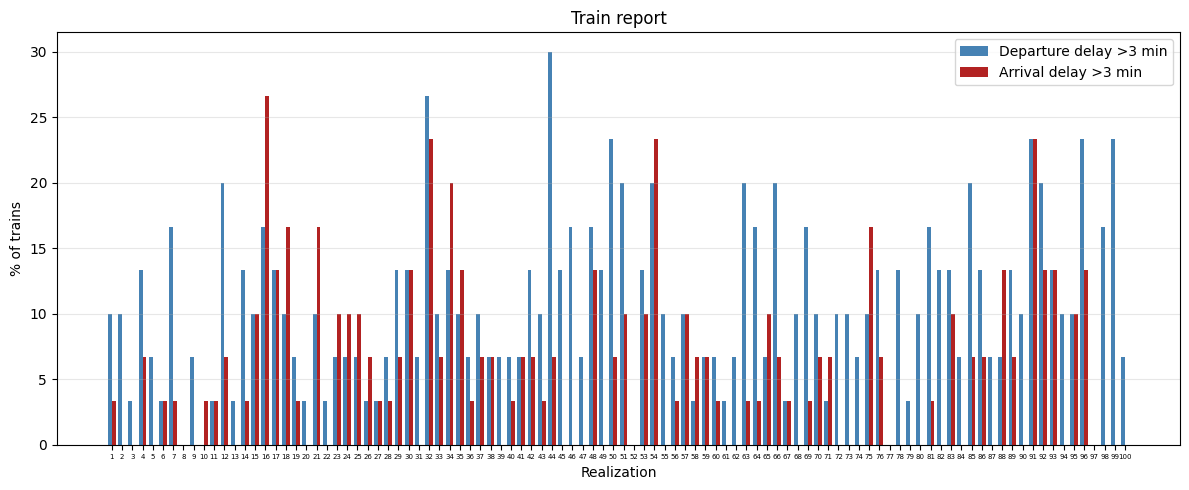

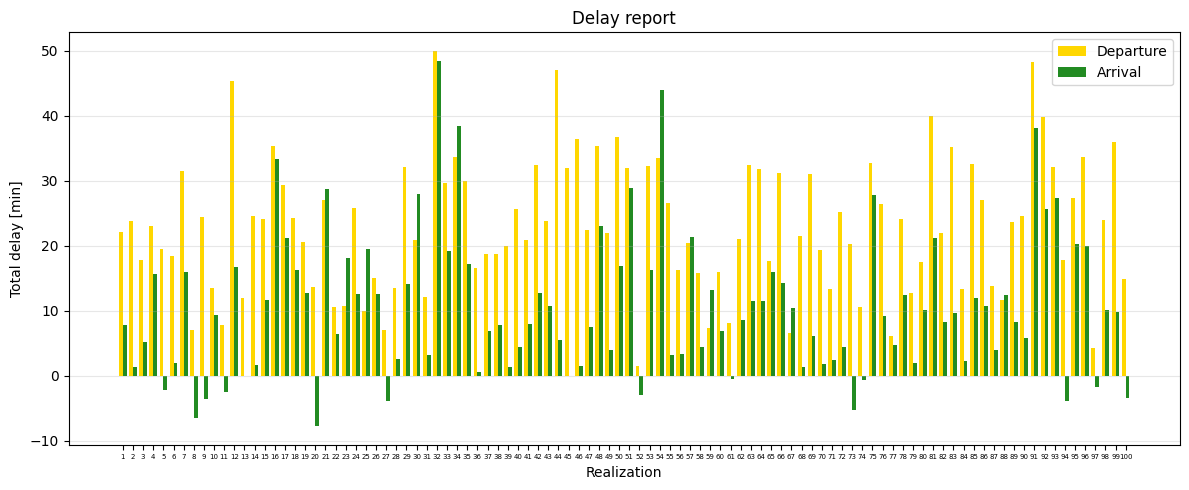

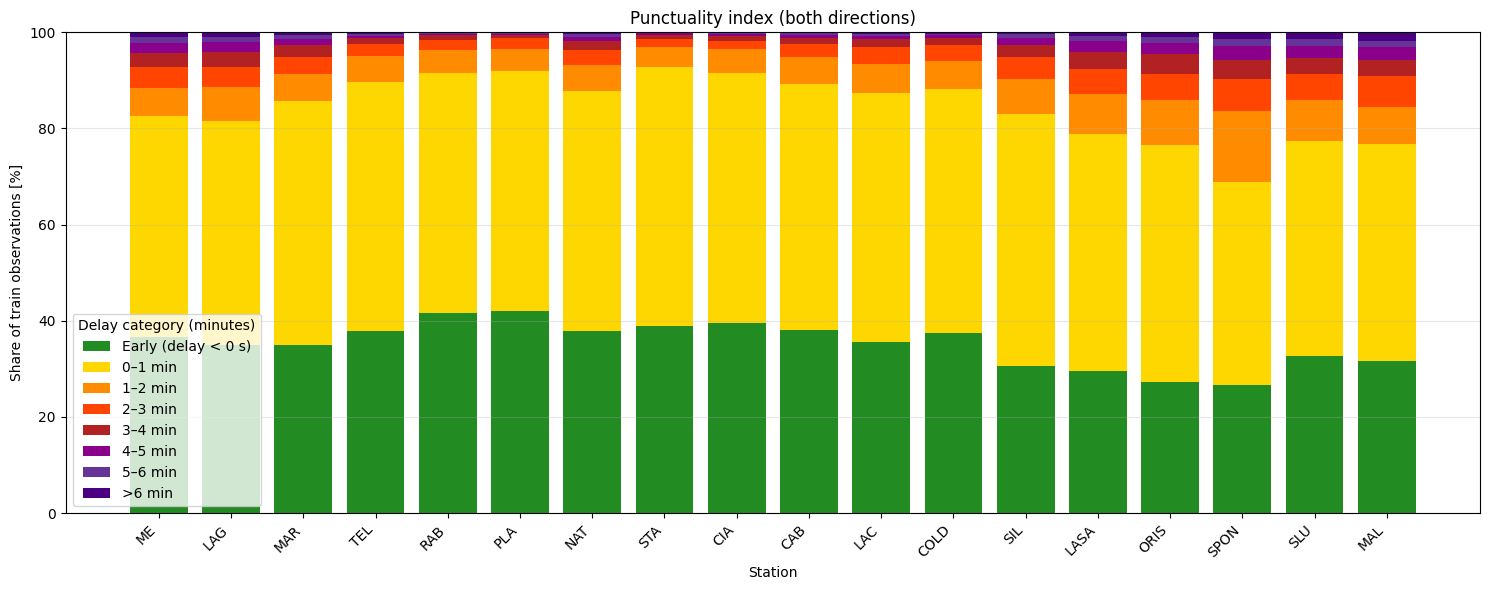

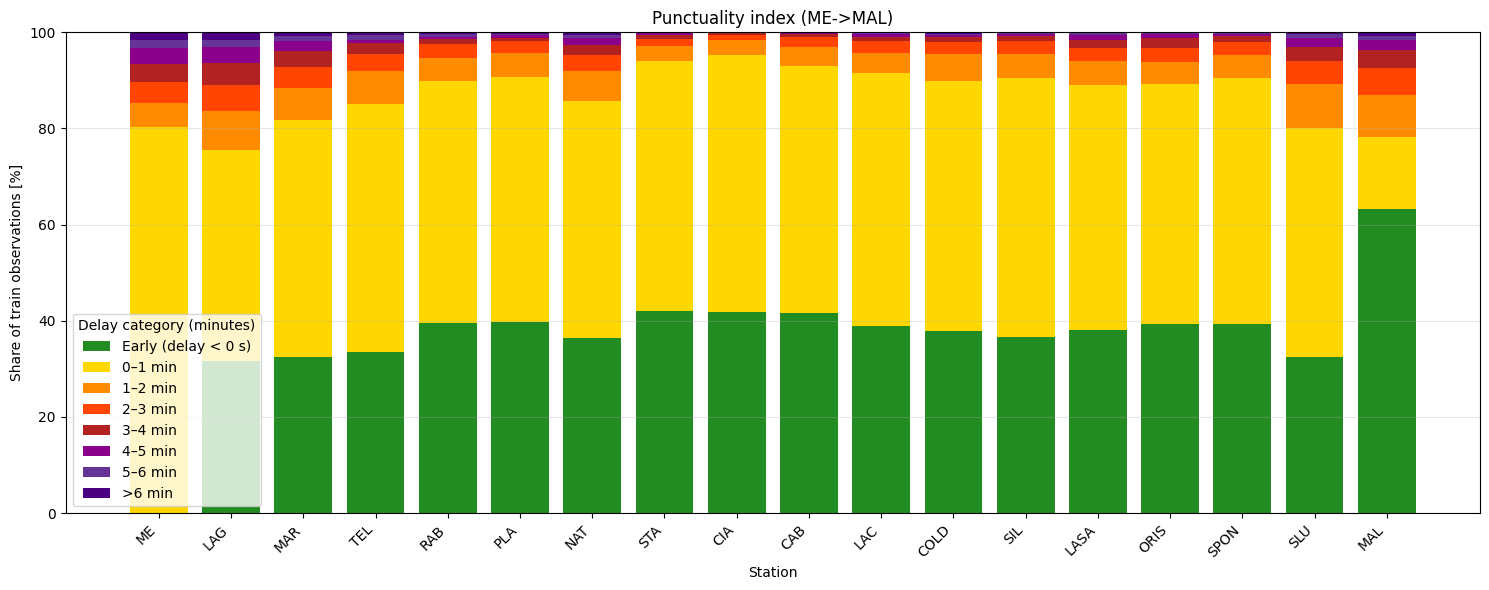

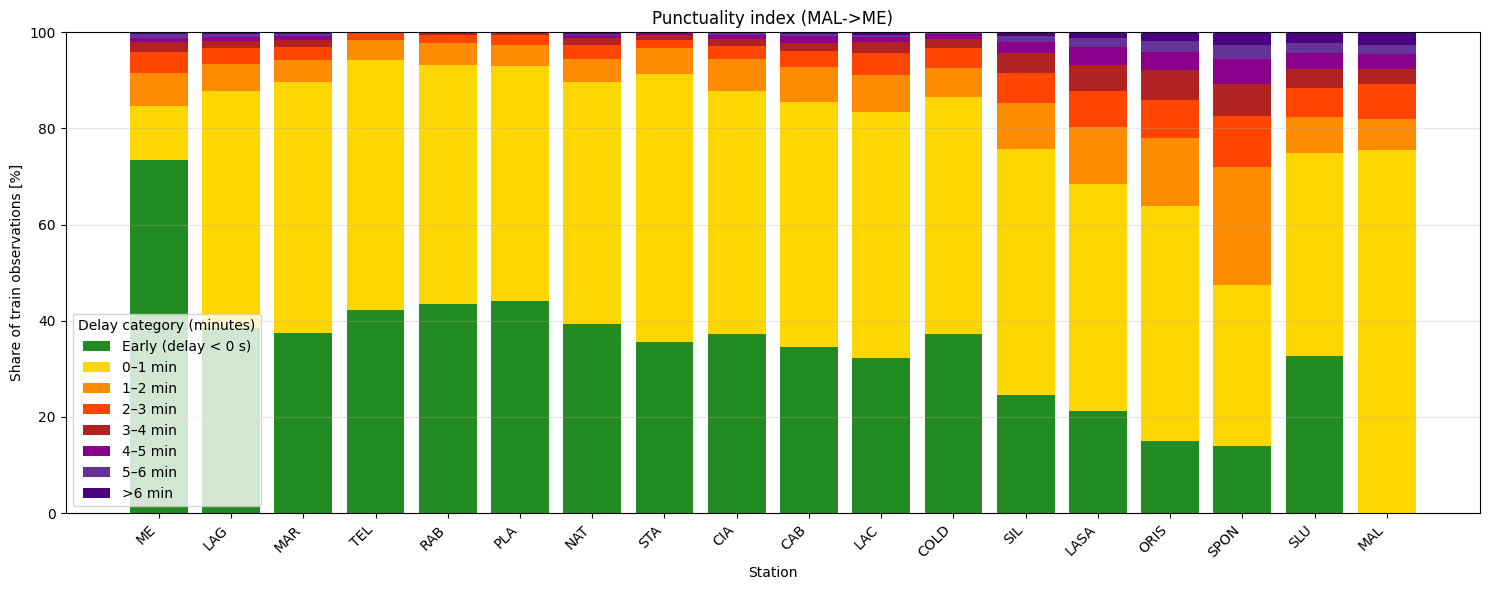

In [16]:
rp.plot_train_report(stats, output_dir=scenario_dir)
rp.plot_delay_report(stats, output_dir=scenario_dir)
rp.plot_punctuality_index(stats, output_dir=scenario_dir)
rp.plot_punctuality_index_me_to_mal(stats, output_dir=scenario_dir)
rp.plot_punctuality_index_mal_to_me(stats, output_dir=scenario_dir)

In [17]:
travel_report = rp.summarize_travel_time_report(G_scheduled, realized_graphs)
rp.print_travel_time_report(travel_report)

Scheduled timetable report
------------------------------------------------------------------------
 fast trains: scheduled 57.0 min/train (10 trains); realized avg 56.8 min
 slow trains: scheduled 83.3 min/train (20 trains); realized avg 82.8 min
------------------------------------------------------------------------


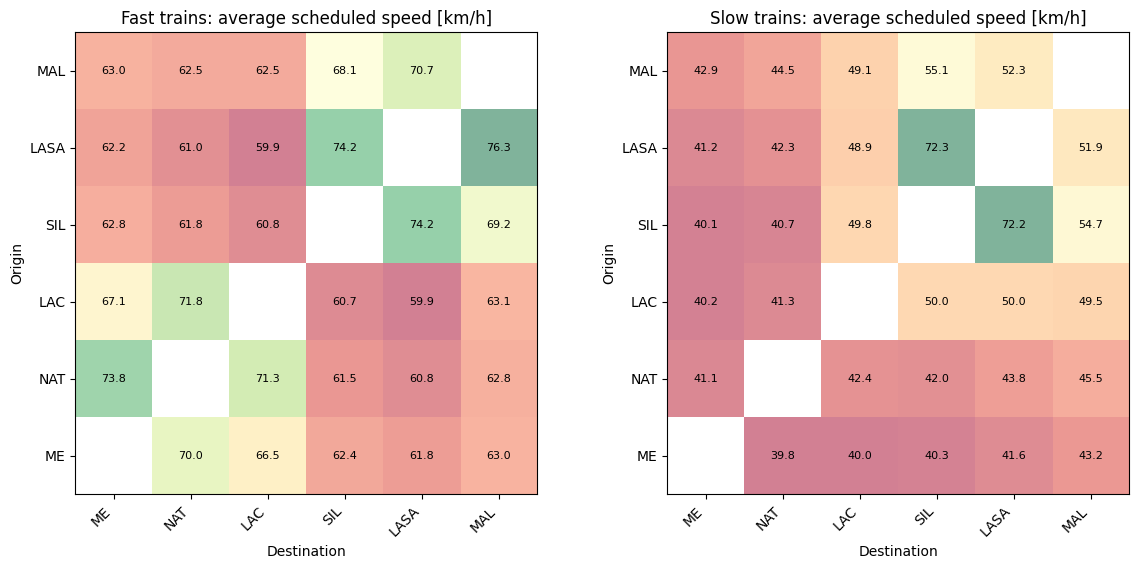

(array([[62.96633548, 62.5096248 , 62.53901193, 68.11286449, 70.72242744,
                 nan],
        [62.159447  , 60.99510404, 59.94019088, 74.17241379,         nan,
         76.25547653],
        [62.81218837, 61.75083612, 60.8150495 ,         nan, 74.17241379,
         69.18083624],
        [67.05257798, 71.7843594 ,         nan, 60.69486166, 59.87669492,
         63.14862385],
        [73.78078292,         nan, 71.30975207, 61.4937552 , 60.8090299 ,
         62.84280443],
        [        nan, 69.96310461, 66.50227273, 62.40880734, 61.82704354,
         63.04002341]]),
 array([[42.94217141, 44.52661381, 49.10501505, 55.05803301, 52.27669797,
                 nan],
        [41.16589234, 42.30553095, 48.89193975, 72.30252101,         nan,
         51.88162606],
        [40.12127612, 40.66411376, 49.81609116,         nan, 72.20153983,
         54.74024006],
        [40.20905288, 41.2650853 ,         nan, 49.97822674, 49.95458333,
         49.49941823],
        [41.07945688,       

In [18]:
rp.plot_speed_matrices([G_scheduled], nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)

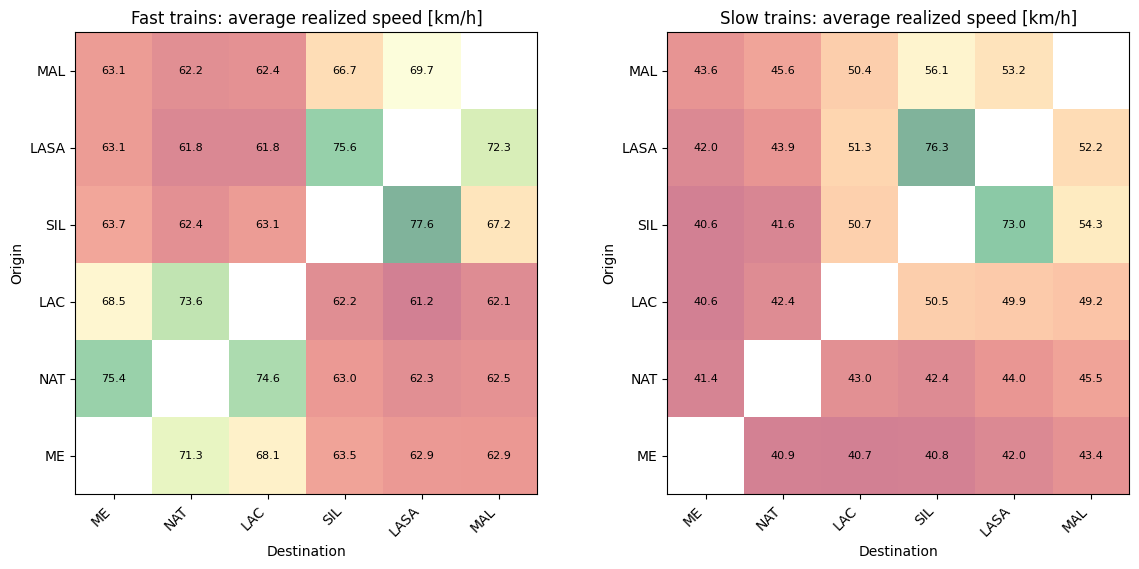

(array([[63.08514768, 62.24744354, 62.43912308, 66.65109876, 69.66730807,
                 nan],
        [63.10968248, 61.80101139, 61.80921631, 75.5843142 ,         nan,
         72.3327198 ],
        [63.71334516, 62.3719069 , 63.09660937,         nan, 77.64582017,
         67.180773  ],
        [68.51635372, 73.5725405 ,         nan, 62.19062697, 61.21023376,
         62.07043181],
        [75.41117174,         nan, 74.62720203, 62.9968025 , 62.26192155,
         62.50831034],
        [        nan, 71.28991525, 68.05391954, 63.48318141, 62.94523638,
         62.93668712]]),
 array([[43.64627001, 45.64806223, 50.38149275, 56.08922224, 53.2050924 ,
                 nan],
        [42.00544815, 43.85042147, 51.31771784, 76.27450254,         nan,
         52.16756292],
        [40.5651716 , 41.58842317, 50.70247223,         nan, 73.02484696,
         54.33295659],
        [40.6018912 , 42.41168297,         nan, 50.46012128, 49.92891279,
         49.21823739],
        [41.39158453,       

In [19]:
rp.plot_speed_matrices(realized_graphs, nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)

In [20]:
stop

NameError: name 'stop' is not defined

# Manual Perturbation

## Propagation

In [ ]:
#inject delays manually
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{edge:0}]


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [ ]:
for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(
    zip(node_perturbations, edge_perturbations, realized_graphs)
):
    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    print(f"\nScenario {i}")
    print("-" * 100)

    for train in sorted(arrival_report):
        r = arrival_report[train]

        print(
            f"Train {train:>2}: "
            f"dep_sched={format_time(r['dep_sched'])}   "
            f"dep_real={format_time(r['dep_real'])}   "
            f"arr_sched={format_time(r['arr_sched'])}   "
            f"arr_real={format_time(r['arr_real'])}   "
            f"delay={format_time(r['delay'])}"
        )

In [ ]:
u = (15, 'Dev_TEL_01', 'arr', 6) 
v = (31, 'Dev_TEL_01', 'dep', 34)
gap = float(realized_graphs[0].nodes[v]["time"]) - float(realized_graphs[0].nodes[u]["time"])

gap

In [ ]:
# Print active headway edges in realized_graphs[1]
try:
    G = realized_graphs[1]
except Exception as e:
    print("realized_graphs[1] not available in this context:", e)
else:
    active_headways = []
    for u, v, data in G.edges(data=True):
        if data.get("kind") == "headway" and data.get("is_active") is not True:
            active_headways.append((u, v, data))

    print(f"Active headway edges in realized_graphs[1]: {len(active_headways)}")
    for u, v, d in active_headways:
        print(u, v, d)
